# FloralArea 2.0: Comprehensive Analysis and Visualization

This notebook contains the analysis for three experiments evaluating FloralArea 2.0:

1. **Experiment 1**: Indoor Context - Benchmark FloralArea 2.0 vs FloralArea 1.0
2. **Experiment 2**: Outdoor Context - Evaluating FloralArea 2.0 with SAM3 in complex environments
3. **Experiment 3**: Distance-based vs Reference-based Area Estimation

---

## Table of Contents
- [Setup and Imports](#setup)
- [Experiment 1: Indoor Benchmark](#exp1)
- [Experiment 2: Outdoor Evaluation](#exp2)
- [Experiment 3: Distance vs Reference-Based Methods](#exp3)
- [Summary and Conclusions](#summary)

---

<a id='setup'></a>
## Setup and Imports

In [37]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set style for publication-quality figures
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")

# Font settings for consistency
font = {'family': 'Arial', 'weight': 'normal'}
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['figure.figsize'] = (12, 8)

print("✓ Libraries loaded successfully")
print("✓ Visualization settings configured")

✓ Libraries loaded successfully
✓ Visualization settings configured


### Helper Functions

In [43]:


def calculate_metrics(measured, predicted):
    """
    Calculate comprehensive regression metrics.
    
    Parameters:
    -----------
    measured : array-like
        Ground truth measurements
    predicted : array-like
        Model predictions
    
    Returns:
    --------
    dict : Dictionary containing all metrics
    """
    # Linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(measured, predicted)
    
    # R-squared and RMSE
    r2 = r2_score(measured, predicted)
    rmse = np.sqrt(mean_squared_error(measured, predicted))
    
    # Bias calculations
    bias = predicted - measured
    mean_bias = np.mean(bias)
    relative_bias = np.mean((bias / measured) * 100)
    
    # Residuals
    y_pred_line = slope * measured + intercept
    residuals = predicted - y_pred_line
    
    return {
        'slope': slope,
        'intercept': intercept,
        'r_value': r_value,
        'r2': r2,
        'p_value': p_value,
        'std_err': std_err,
        'rmse': rmse,
        'mean_bias': mean_bias,
        'relative_bias': relative_bias,
        'residuals': residuals,
        'n': len(measured)
    }

def plot_regression_analysis(measured, predicted, method_name, ax=None, color='steelblue'):
    """
    Create a standardized regression plot with statistics.
    
    Parameters:
    -----------
    measured : array-like
        Ground truth measurements
    predicted : array-like
        Model predictions
    method_name : str
        Name of the method being evaluated
    ax : matplotlib axis object, optional
        Axis to plot on. If None, creates new figure
    color : str, optional
        Color for scatter points
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    
    metrics = calculate_metrics(measured, predicted)
    
    # 1:1 line
    max_val = max(measured.max(), predicted.max())
    ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1, label='1:1 line', alpha=0.5, color='gray')
    
    # Scatter plot
    ax.scatter(measured, predicted, color=color, s=60, alpha=0.6, edgecolors='black', linewidth=0.5)
    
    # Regression line
    x_line = np.array([measured.min(), measured.max()])
    y_line = metrics['slope'] * x_line + metrics['intercept']
    ax.plot(x_line, y_line, 'r-', linewidth=2, label='Regression line', color='gray')
    
    # Labels and title
    ax.set_xlabel('Measured Area (cm²)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Predicted Area (cm²)', fontsize=14, fontweight='bold')
    #ax.set_title(f'{method_name}', fontsize=16, fontweight='bold', pad=20)
    
    # Statistics text box
    stats_text = (
        f"{method_name}\n"
        f"y = {metrics['intercept']:.2f} + {metrics['slope']:.2f}x\n"
        f"R² = {metrics['r2']:.3f}\n"
        f"RMSE = {metrics['rmse']:.2f} cm²\n"
        f"p_value < {metrics['p_value']:.3f} \n"
        f"Bias = {metrics['mean_bias']:.2f} cm²\n"
        f"n = {metrics['n']}"
    )
    
    # Position text box in upper left
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
            fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.legend(loc='lower right', fontsize=10)
    ax.set_aspect('equal', adjustable='box')
    
    return metrics

def plot_residuals(measured, predicted, method_name, ax=None, color='steelblue'):
    """
    Create a residual plot.
    
    Parameters:
    -----------
    measured : array-like
        Ground truth measurements
    predicted : array-like
        Model predictions
    method_name : str
        Name of the method being evaluated
    ax : matplotlib axis object, optional
        Axis to plot on
    color : str, optional
        Color for scatter points
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    metrics = calculate_metrics(measured, predicted)
    residuals = metrics['residuals']
    fitted = metrics['slope'] * measured + metrics['intercept']
    
    # Scatter plot
    ax.scatter(fitted, residuals, color=color, s=60, alpha=0.6, edgecolors='black', linewidth=0.5)
    
    # Zero line
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=2, label='Zero line')
    
    # Mean residual line
    mean_res = np.mean(residuals)
    ax.axhline(y=mean_res, color='gray', linestyle='-', linewidth=1.5, 
               alpha=0.6, label=f'Mean residual: {mean_res:.2f}')
    
    # Labels
    ax.set_xlabel('Fitted Values (cm²)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Residuals (cm²)', fontsize=14, fontweight='bold')
    #ax.set_title(f'Residual Plot - {method_name}', fontsize=16, fontweight='bold', pad=20)
    
    # Statistics
    std_res = np.std(residuals)
    stats_text = f"Std Dev: {std_res:.2f} cm²"
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
            fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.legend(loc='upper right', fontsize=10)
    
    return metrics

print("✓ Helper functions defined")

✓ Helper functions defined


---
<a id='exp1'></a>
## Experiment 1: Indoor Context - FloralArea 2.0 vs 1.0 Benchmark

This experiment evaluates FloralArea 2.0 using the same indoor dataset from the original FloralArea 1.0 paper. This allows us to directly compare the performance improvements from using SAM3 for segmentation.

### Key Research Questions:
1. How does FloralArea 2.0 perform compared to FloralArea 1.0 on the same dataset?
2. Does the improved segmentation model (SAM3) provide better accuracy?
3. What is the magnitude of improvement in key metrics (R², RMSE, bias)?

### Load Data for Experiment 1

In [39]:
# TODO: Load your indoor dataset here
# This should be the same dataset used in FloralArea 1.0
# Expected columns: 'measured_area_cm2', 'floralarea_1.0_cm2', 'floralarea_2.0_cm2'

# Example format:
indoor_data = pd.read_csv('/Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/output/indoor_reference_based_analysis_data.csv')

# For demonstration, I'll create a placeholder
# REPLACE THIS with your actual data loading code
print("📊 Load your indoor benchmark dataset here")
print("Expected columns: 'measured_area_cm2', 'floralarea_1.0_cm2', 'floralarea_2.0_cm2'")
print("\nExample:")
print("indoor_data = pd.read_csv('indoor_benchmark_data.csv')")

# Uncomment and modify this line with your actual file path:
# indoor_data = pd.read_csv('your_file_path_here.csv')

📊 Load your indoor benchmark dataset here
Expected columns: 'measured_area_cm2', 'floralarea_1.0_cm2', 'floralarea_2.0_cm2'

Example:
indoor_data = pd.read_csv('indoor_benchmark_data.csv')


### Data Exploration

In [40]:
# Uncomment when data is loaded:
print("Dataset Shape:", indoor_data.shape)
print("\nFirst few rows:")
display(indoor_data.head())
print("\nDataset Statistics:")
display(indoor_data.describe())
print("\nMissing values:")
print(indoor_data.isnull().sum())

Dataset Shape: (75, 5)

First few rows:


,Unnamed: 0,file,floralarea_2.0_cm2,measured_area_cm2,floralarea_1.0_cm2
0,0,PXL_20240214_172530114_80cm_F6_.jpg,46.879243,51.309575,33.26
1,1,PXL_20240214_173554009_80cm_F11_.jpg,3.764198,3.367735,18.29
2,2,PXL_20240214_175708911_100cm_F23_.jpg,28.579909,35.916057,38.33
3,3,PXL_20240214_175352365_100cm_F21_.jpg,20.085721,19.696735,28.46
4,4,PXL_20240214_174000188_80cm_F13_.jpg,132.484488,131.586834,131.07



Dataset Statistics:


,Unnamed: 0,floralarea_2.0_cm2,measured_area_cm2,floralarea_1.0_cm2
count,75.000000,75.000000,75.000000,75.000000
mean,37.000000,68.246686,68.018101,74.467600
std,21.794495,79.431968,79.437059,74.656923
min,0.000000,0.000000,2.883865,6.560000
25%,18.500000,19.169761,18.767704,28.960000
50%,37.000000,37.699477,38.670890,42.460000
75%,55.500000,96.103340,90.590141,96.165000
max,74.000000,378.986731,359.605732,363.060000



Missing values:
Unnamed: 0            0
file                  0
floralarea_2.0_cm2    0
measured_area_cm2     0
floralarea_1.0_cm2    0
dtype: int64


### Comparative Analysis: FloralArea 1.0 vs 2.0

In [41]:
#indoor_data[indoor_data['measured_area_cm2'] > 350]
# PXL_20240214_174605604_80cm_F15_.jpg

indoor_data = indoor_data[indoor_data['file'] != 'PXL_20240214_174605604_80cm_F15_.jpg']

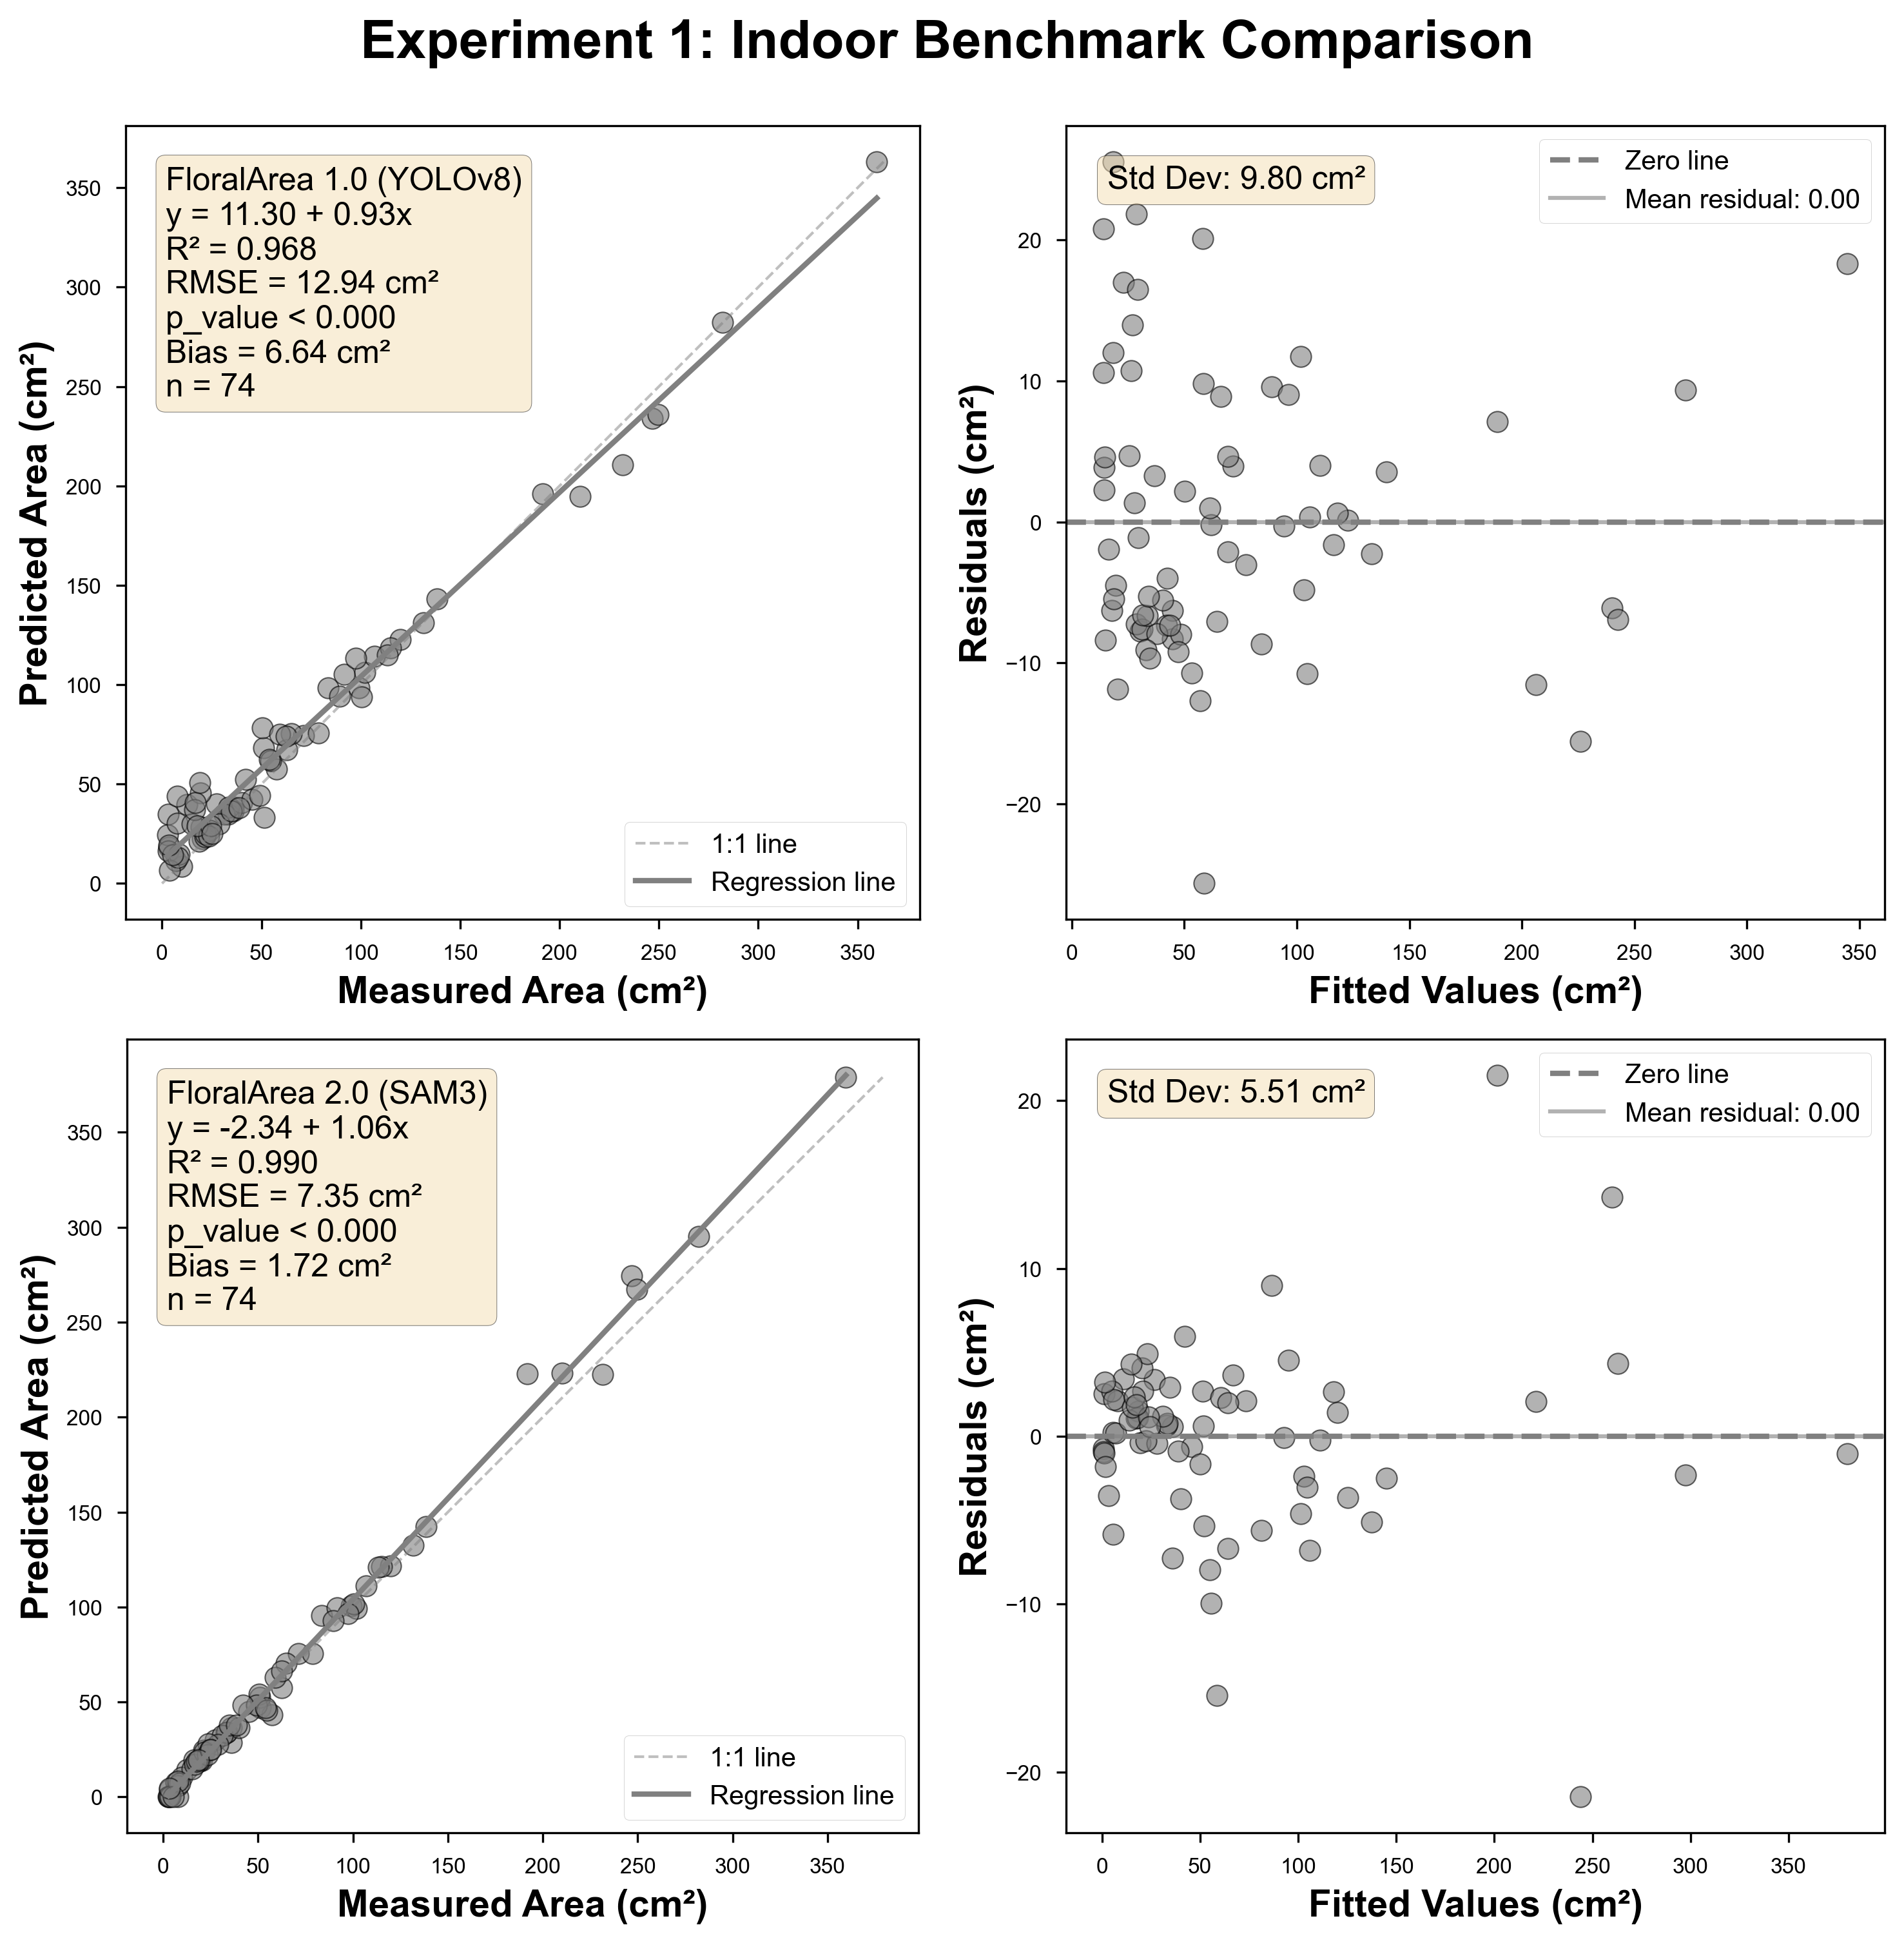

📈 Visualization code ready - uncomment after loading data


In [44]:
# Uncomment when data is loaded:

# Create side-by-side comparison
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# FloralArea 1.0 - Regression
metrics_v1_reg = plot_regression_analysis(
    indoor_data['measured_area_cm2'],
    indoor_data['floralarea_1.0_cm2'],
    'FloralArea 1.0 (YOLOv8)',
    ax=axes[0, 0],
    color='gray'
)

# FloralArea 1.0 - Residuals
plot_residuals(
    indoor_data['measured_area_cm2'],
    indoor_data['floralarea_1.0_cm2'],
    'FloralArea 1.0 (YOLOv8)',
    ax=axes[0, 1],
    color='gray'
)

# FloralArea 2.0 - Regression
metrics_v2_reg = plot_regression_analysis(
    indoor_data['measured_area_cm2'],
    indoor_data['floralarea_2.0_cm2'],
    'FloralArea 2.0 (SAM3)',
    ax=axes[1, 0],
    color='gray'
)

# FloralArea 2.0 - Residuals
plot_residuals(
    indoor_data['measured_area_cm2'],
    indoor_data['floralarea_2.0_cm2'],
    'FloralArea 2.0 (SAM3)',
    ax=axes[1, 1],
    color='gray'
)

plt.suptitle('Experiment 1: Indoor Benchmark Comparison', 
             fontsize=20, fontweight='bold', y=1.00)
plt.tight_layout()
#plt.savefig('experiment1_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("📈 Visualization code ready - uncomment after loading data")

### Performance Improvement Summary

In [16]:
# Uncomment when data is loaded:

# Create comparison table
comparison_df = pd.DataFrame({
    'Metric': ['R²', 'RMSE (cm²)', 'Mean Bias (cm²)', 'Relative Bias (%)', 'n'],
    'FloralArea 1.0': [
        f"{metrics_v1_reg['r2']:.3f}",
        f"{metrics_v1_reg['rmse']:.2f}",
        f"{metrics_v1_reg['mean_bias']:.2f}",
        f"{metrics_v1_reg['relative_bias']:.2f}",
        metrics_v1_reg['n']
    ],
    'FloralArea 2.0': [
        f"{metrics_v2_reg['r2']:.3f}",
        f"{metrics_v2_reg['rmse']:.2f}",
        f"{metrics_v2_reg['mean_bias']:.2f}",
        f"{metrics_v2_reg['relative_bias']:.2f}",
        metrics_v2_reg['n']
    ],
    'Improvement': [
        f"{((metrics_v2_reg['r2'] - metrics_v1_reg['r2']) / metrics_v1_reg['r2'] * 100):.1f}%",
        f"{((metrics_v2_reg['rmse'] - metrics_v1_reg['rmse']) / metrics_v1_reg['rmse'] * 100):.1f}%",
        f"{((metrics_v2_reg['mean_bias'] - metrics_v1_reg['mean_bias']) / abs(metrics_v1_reg['mean_bias']) * 100):.1f}%",
        f"{((metrics_v2_reg['relative_bias'] - metrics_v1_reg['relative_bias']) / abs(metrics_v1_reg['relative_bias']) * 100):.1f}%",
        '-'
    ]
})

print("\n" + "="*80)
print("EXPERIMENT 1: PERFORMANCE COMPARISON SUMMARY")
print("="*80)
display(comparison_df)
print("="*80)

print("📊 Summary table code ready - uncomment after loading data")


EXPERIMENT 1: PERFORMANCE COMPARISON SUMMARY


,Metric,FloralArea 1.0,FloralArea 2.0,Improvement
0,R²,0.968,0.990,2.3%
1,RMSE (cm²),12.94,7.35,-43.2%
2,Mean Bias (cm²),6.64,1.72,-74.0%
3,Relative Bias (%),76.65,-5.99,-107.8%
4,n,74,74,-


📊 Summary table code ready - uncomment after loading data


---
<a id='exp2'></a>
## Experiment 2: Outdoor Context Evaluation

This experiment evaluates FloralArea 2.0 in complex outdoor environments where FloralArea 1.0 struggles due to background complexity. The SAM3 segmentation model should handle these challenging conditions better.

### Key Research Questions:
1. How well does FloralArea 2.0 perform in outdoor environments with complex backgrounds?
2. What is the accuracy of floral area estimation in natural field conditions?
3. Are there specific outdoor conditions that still challenge the system?

### Load Data for Experiment 2

In [45]:
# TODO: Load your outdoor dataset here
# Expected columns: 'measured_area_cm2', 'predicted_area_cm2'

# Example:
outdoor_data = pd.read_csv('/Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/output/outdoor_reference_based_analysis_data.csv')

print("📊 Load your outdoor dataset here")
print("Expected columns: 'measured_area_cm2', 'predicted_area_cm2'")
print("\nExample:")
print("outdoor_data = pd.read_csv('outdoor_data.csv')")

# Uncomment and modify this line with your actual file path:
# outdoor_data = pd.read_csv('your_outdoor_file_path_here.csv')

📊 Load your outdoor dataset here
Expected columns: 'measured_area_cm2', 'predicted_area_cm2'

Example:
outdoor_data = pd.read_csv('outdoor_data.csv')


### Data Exploration

In [46]:
# Uncomment when data is loaded:
print("Dataset Shape:", outdoor_data.shape)
print("\nFirst few rows:")
display(outdoor_data.head())
print("\nDataset Statistics:")
display(outdoor_data.describe())
print("\nMissing values:")
print(outdoor_data.isnull().sum())

Dataset Shape: (61, 5)

First few rows:


,Unnamed: 0,file,measured_area_cm2,floralarea_1.0_cm2,floralarea_2.0_cm2
0,0,1_229..jpg,5.270,6.125508554868193,3.812700
1,1,1_213..jpg,169.551,No reference object,198.279197
2,2,1_182..jpg,628.632,875.5578370978782,518.325069
3,3,1_194..jpg,160.903,97.5,173.460693
4,4,1_225..jpg,219.780,71.44821032625912,203.812028



Dataset Statistics:


,Unnamed: 0,measured_area_cm2,floralarea_2.0_cm2
count,61.000000,61.000000,61.000000
mean,30.000000,278.070803,244.760321
std,17.752934,398.417501,361.417282
min,0.000000,5.270000,0.000000
25%,15.000000,47.325000,52.683643
50%,30.000000,119.861000,104.213058
75%,45.000000,359.273000,264.862069
max,60.000000,2071.694000,1984.121268



Missing values:
Unnamed: 0            0
file                  0
measured_area_cm2     0
floralarea_1.0_cm2    0
floralarea_2.0_cm2    0
dtype: int64


### Outdoor Performance Analysis

In [47]:
def isDrop(x):
    try:
        float(x)
        return True
    except:
        return False
    
outdoor_data_clean = outdoor_data[outdoor_data['floralarea_1.0_cm2'].apply(isDrop)]

In [48]:
outdoor_data_clean['measured_area_cm2'] = outdoor_data_clean['measured_area_cm2'].apply(lambda x: float(x))
outdoor_data_clean['floralarea_1.0_cm2'] = outdoor_data_clean['floralarea_1.0_cm2'].apply(lambda x: float(x))
outdoor_data_clean['floralarea_2.0_cm2'] = outdoor_data_clean['floralarea_2.0_cm2'].apply(lambda x: float(x))

In [49]:
outdoor_data_clean_v2 = outdoor_data[outdoor_data['floralarea_2.0_cm2'] != 0.0]

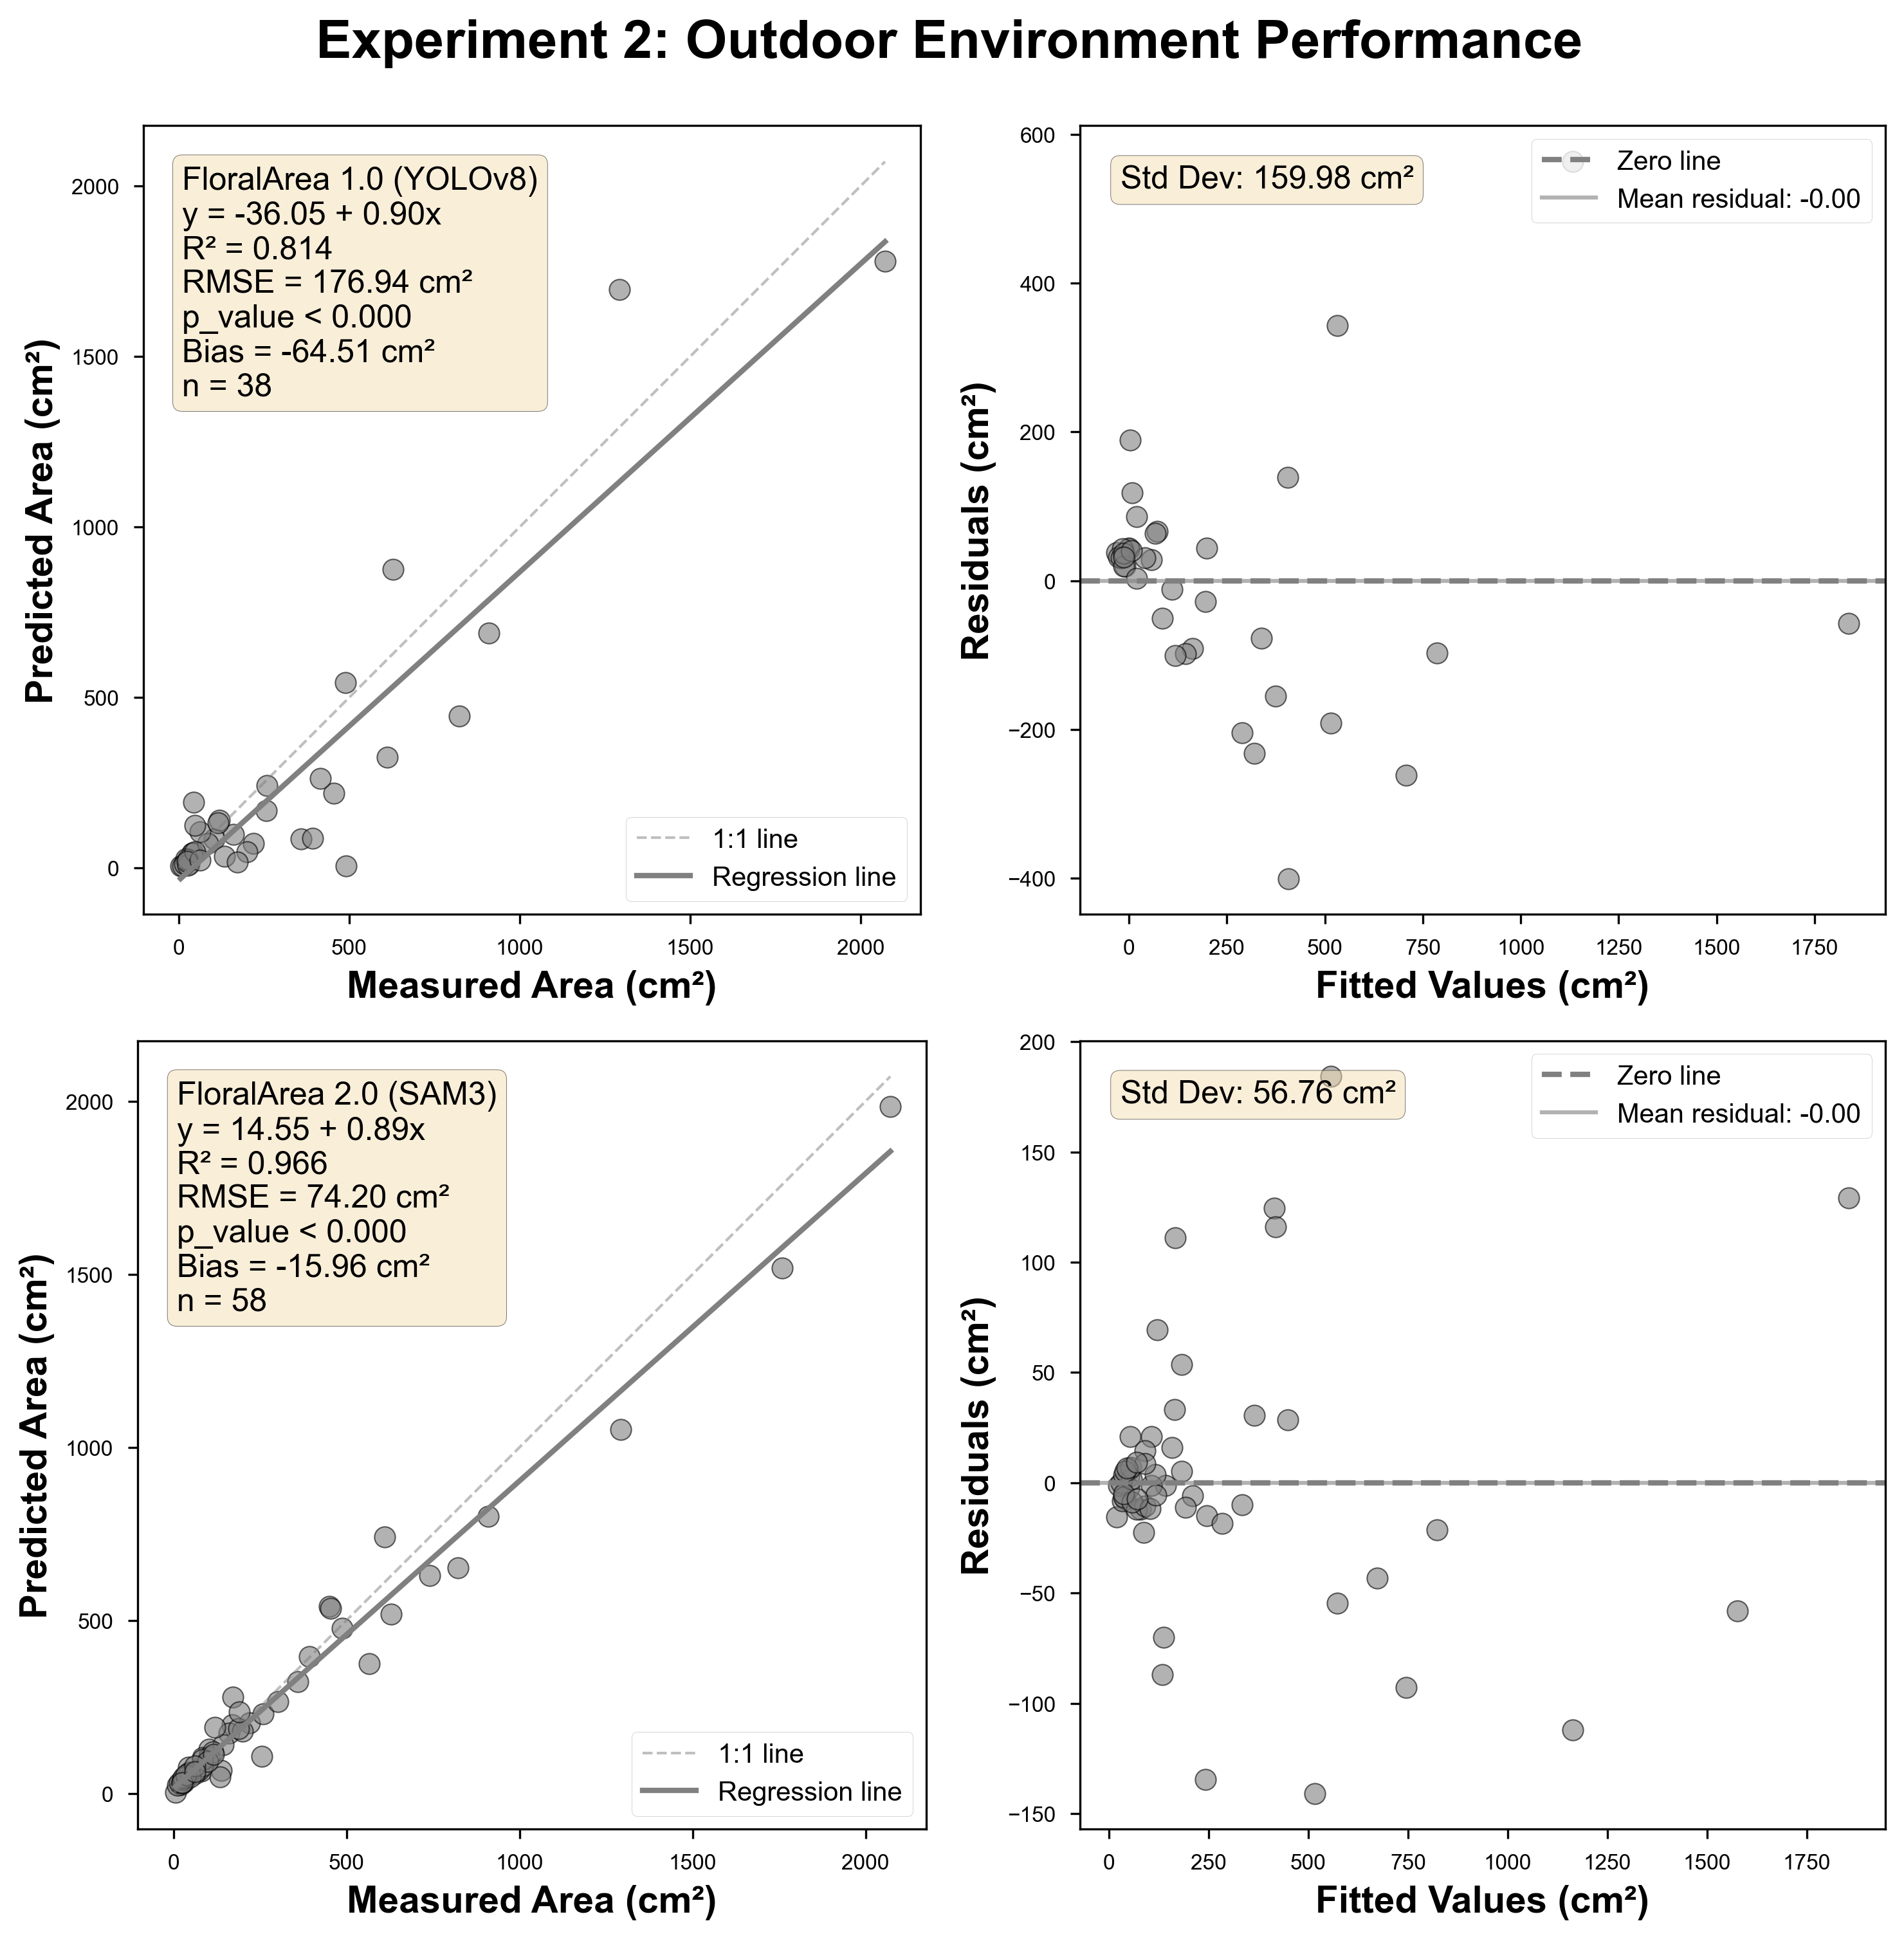

📈 Visualization code ready - uncomment after loading data


In [50]:
# Uncomment when data is loaded:

# Create side-by-side comparison
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# FloralArea 1.0 - Regression
metrics_v1_reg = plot_regression_analysis(
    outdoor_data_clean['measured_area_cm2'],
    outdoor_data_clean['floralarea_1.0_cm2'],
    'FloralArea 1.0 (YOLOv8)',
    ax=axes[0, 0],
    color='gray'
)

# FloralArea 1.0 - Residuals
plot_residuals(
    outdoor_data_clean['measured_area_cm2'],
    outdoor_data_clean['floralarea_1.0_cm2'],
    'FloralArea 1.0 (YOLOv8)',
    ax=axes[0, 1],
    color='gray'
)

# FloralArea 2.0 - Regression
metrics_v2_reg = plot_regression_analysis(
    outdoor_data_clean_v2['measured_area_cm2'],
    outdoor_data_clean_v2['floralarea_2.0_cm2'],
    'FloralArea 2.0 (SAM3)',
    ax=axes[1, 0],
    color='gray'
)

# FloralArea 2.0 - Residuals
plot_residuals(
    outdoor_data_clean_v2['measured_area_cm2'],
    outdoor_data_clean_v2['floralarea_2.0_cm2'],
    'FloralArea 2.0 (SAM3)',
    ax=axes[1, 1],
    color='gray'
)

plt.suptitle('Experiment 2: Outdoor Environment Performance', 
             fontsize=20, fontweight='bold', y=1.00)
plt.tight_layout()
#plt.savefig('experiment1_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("📈 Visualization code ready - uncomment after loading data")

### Outdoor Performance Summary

In [51]:
outdoor_data[outdoor_data['floralarea_2.0_cm2'] == 0.0]

,Unnamed: 0,file,measured_area_cm2,floralarea_1.0_cm2,floralarea_2.0_cm2
41,41,1_217..jpg,201.930,No flower,0.0
47,47,1_220..jpg,490.149,6.645833333333333,0.0
57,57,1_210..jpg,414.469,261.69365810840463,0.0


In [52]:
# Uncomment when data is loaded:

# print("\n" + "="*80)
# print("EXPERIMENT 2: OUTDOOR PERFORMANCE SUMMARY")
# print("="*80)
# print(f"Sample Size (n): {metrics_outdoor['n']}")
# print(f"R² Score: {metrics_outdoor['r2']:.3f}")
# print(f"RMSE: {metrics_outdoor['rmse']:.2f} cm²")
# print(f"Mean Bias: {metrics_outdoor['mean_bias']:.2f} cm²")
# print(f"Relative Bias: {metrics_outdoor['relative_bias']:.2f}%")
# print(f"Regression Equation: y = {metrics_outdoor['intercept']:.2f} + {metrics_outdoor['slope']:.2f}x")
# print(f"P-value: {metrics_outdoor['p_value']:.2e}")
# print("="*80)

print("📊 Outdoor summary code ready - uncomment after loading data")

📊 Outdoor summary code ready - uncomment after loading data


---
<a id='exp3'></a>
## Experiment 3: Distance-Based vs Reference-Based Area Estimation

This experiment compares two approaches for area estimation:
1. **Reference-Based**: Uses a reference object of known size in the image
2. **Distance-Based**: Uses camera-to-flower distance to calculate area

### Methodology:
- Images taken at multiple distances (60cm, 70cm, 80cm, 90cm, 100cm from ground)
- 80cm images used to calibrate flower-to-ground distance
- Calibrated distance used to estimate camera-to-flower distance for other heights

### Key Research Questions:
1. Which method provides better accuracy?
2. How does each method perform across different camera distances?
3. What are the practical implications for field use?

### Load Data for Experiment 3

In [53]:
# TODO: Load your distance comparison dataset here
# Expected columns: 'measured_area_cm2', 'distance_based_cm2', 'reference_based_cm2', 'camera_distance'

# Example:
distance_data = pd.read_csv('/Users/edwardamoah/Documents/GitHub/FloralArea_Web/research/output/indoor_distance_based_analysis_data.csv')

print("📊 Load your distance comparison dataset here")
print("Expected columns: 'measured_area_cm2', 'distance_based_cm2', 'reference_based_cm2', 'camera_distance'")
print("\nExample:")
print("distance_data = pd.read_csv('distance_comparison_data.csv')")

# Uncomment and modify this line with your actual file path:
# distance_data = pd.read_csv('your_distance_file_path_here.csv')

📊 Load your distance comparison dataset here
Expected columns: 'measured_area_cm2', 'distance_based_cm2', 'reference_based_cm2', 'camera_distance'

Example:
distance_data = pd.read_csv('distance_comparison_data.csv')


### Data Exploration

In [54]:
# Uncomment when data is loaded:
print("Dataset Shape:", distance_data.shape)
print("\nFirst few rows:")
display(distance_data.head())
print("\nDataset Statistics:")
display(distance_data.describe())
print("\nCamera distances in dataset:")
print(distance_data['distance_camera_to_ground_cm'].value_counts().sort_index())

Dataset Shape: (45, 6)

First few rows:


,file,flower,distance_camera_to_ground_cm,measured_area_cm2,predicted_distance_based_area_cm2,predicted_reference_based_area_cm2
0,PXL_20240214_175352365_100cm_F21_.jpg,F21,100,19.696735,20.296706,18.239009
1,PXL_20240214_175033319_60cm_F18_.jpg,F18,60,35.987025,19.537758,25.096238
2,PXL_20240214_173904525_100cm_F13_.jpg,F13,100,98.980447,102.626389,96.598299
3,PXL_20240214_173731980_100cm_F12_.jpg,F12,100,2.883865,22.563655,21.890223
4,PXL_20240214_174053319_60cm_F13_.jpg,F13,60,231.612440,132.928302,163.579053



Dataset Statistics:


,distance_camera_to_ground_cm,measured_area_cm2,predicted_distance_based_area_cm2,predicted_reference_based_area_cm2
count,45.000000,45.000000,45.000000,45.000000
mean,81.555556,60.187120,54.117425,56.659334
std,19.650995,65.500113,59.909882,58.492926
min,60.000000,2.883865,2.305775,2.770185
25%,60.000000,16.787063,15.500689,17.007987
50%,90.000000,33.593481,29.199520,27.445567
75%,100.000000,89.522402,78.722928,81.575923
max,100.000000,282.044597,279.055487,246.232245



Camera distances in dataset:
distance_camera_to_ground_cm
60     20
90      3
100    22
Name: count, dtype: int64


### Method Comparison: 4-Panel Analysis

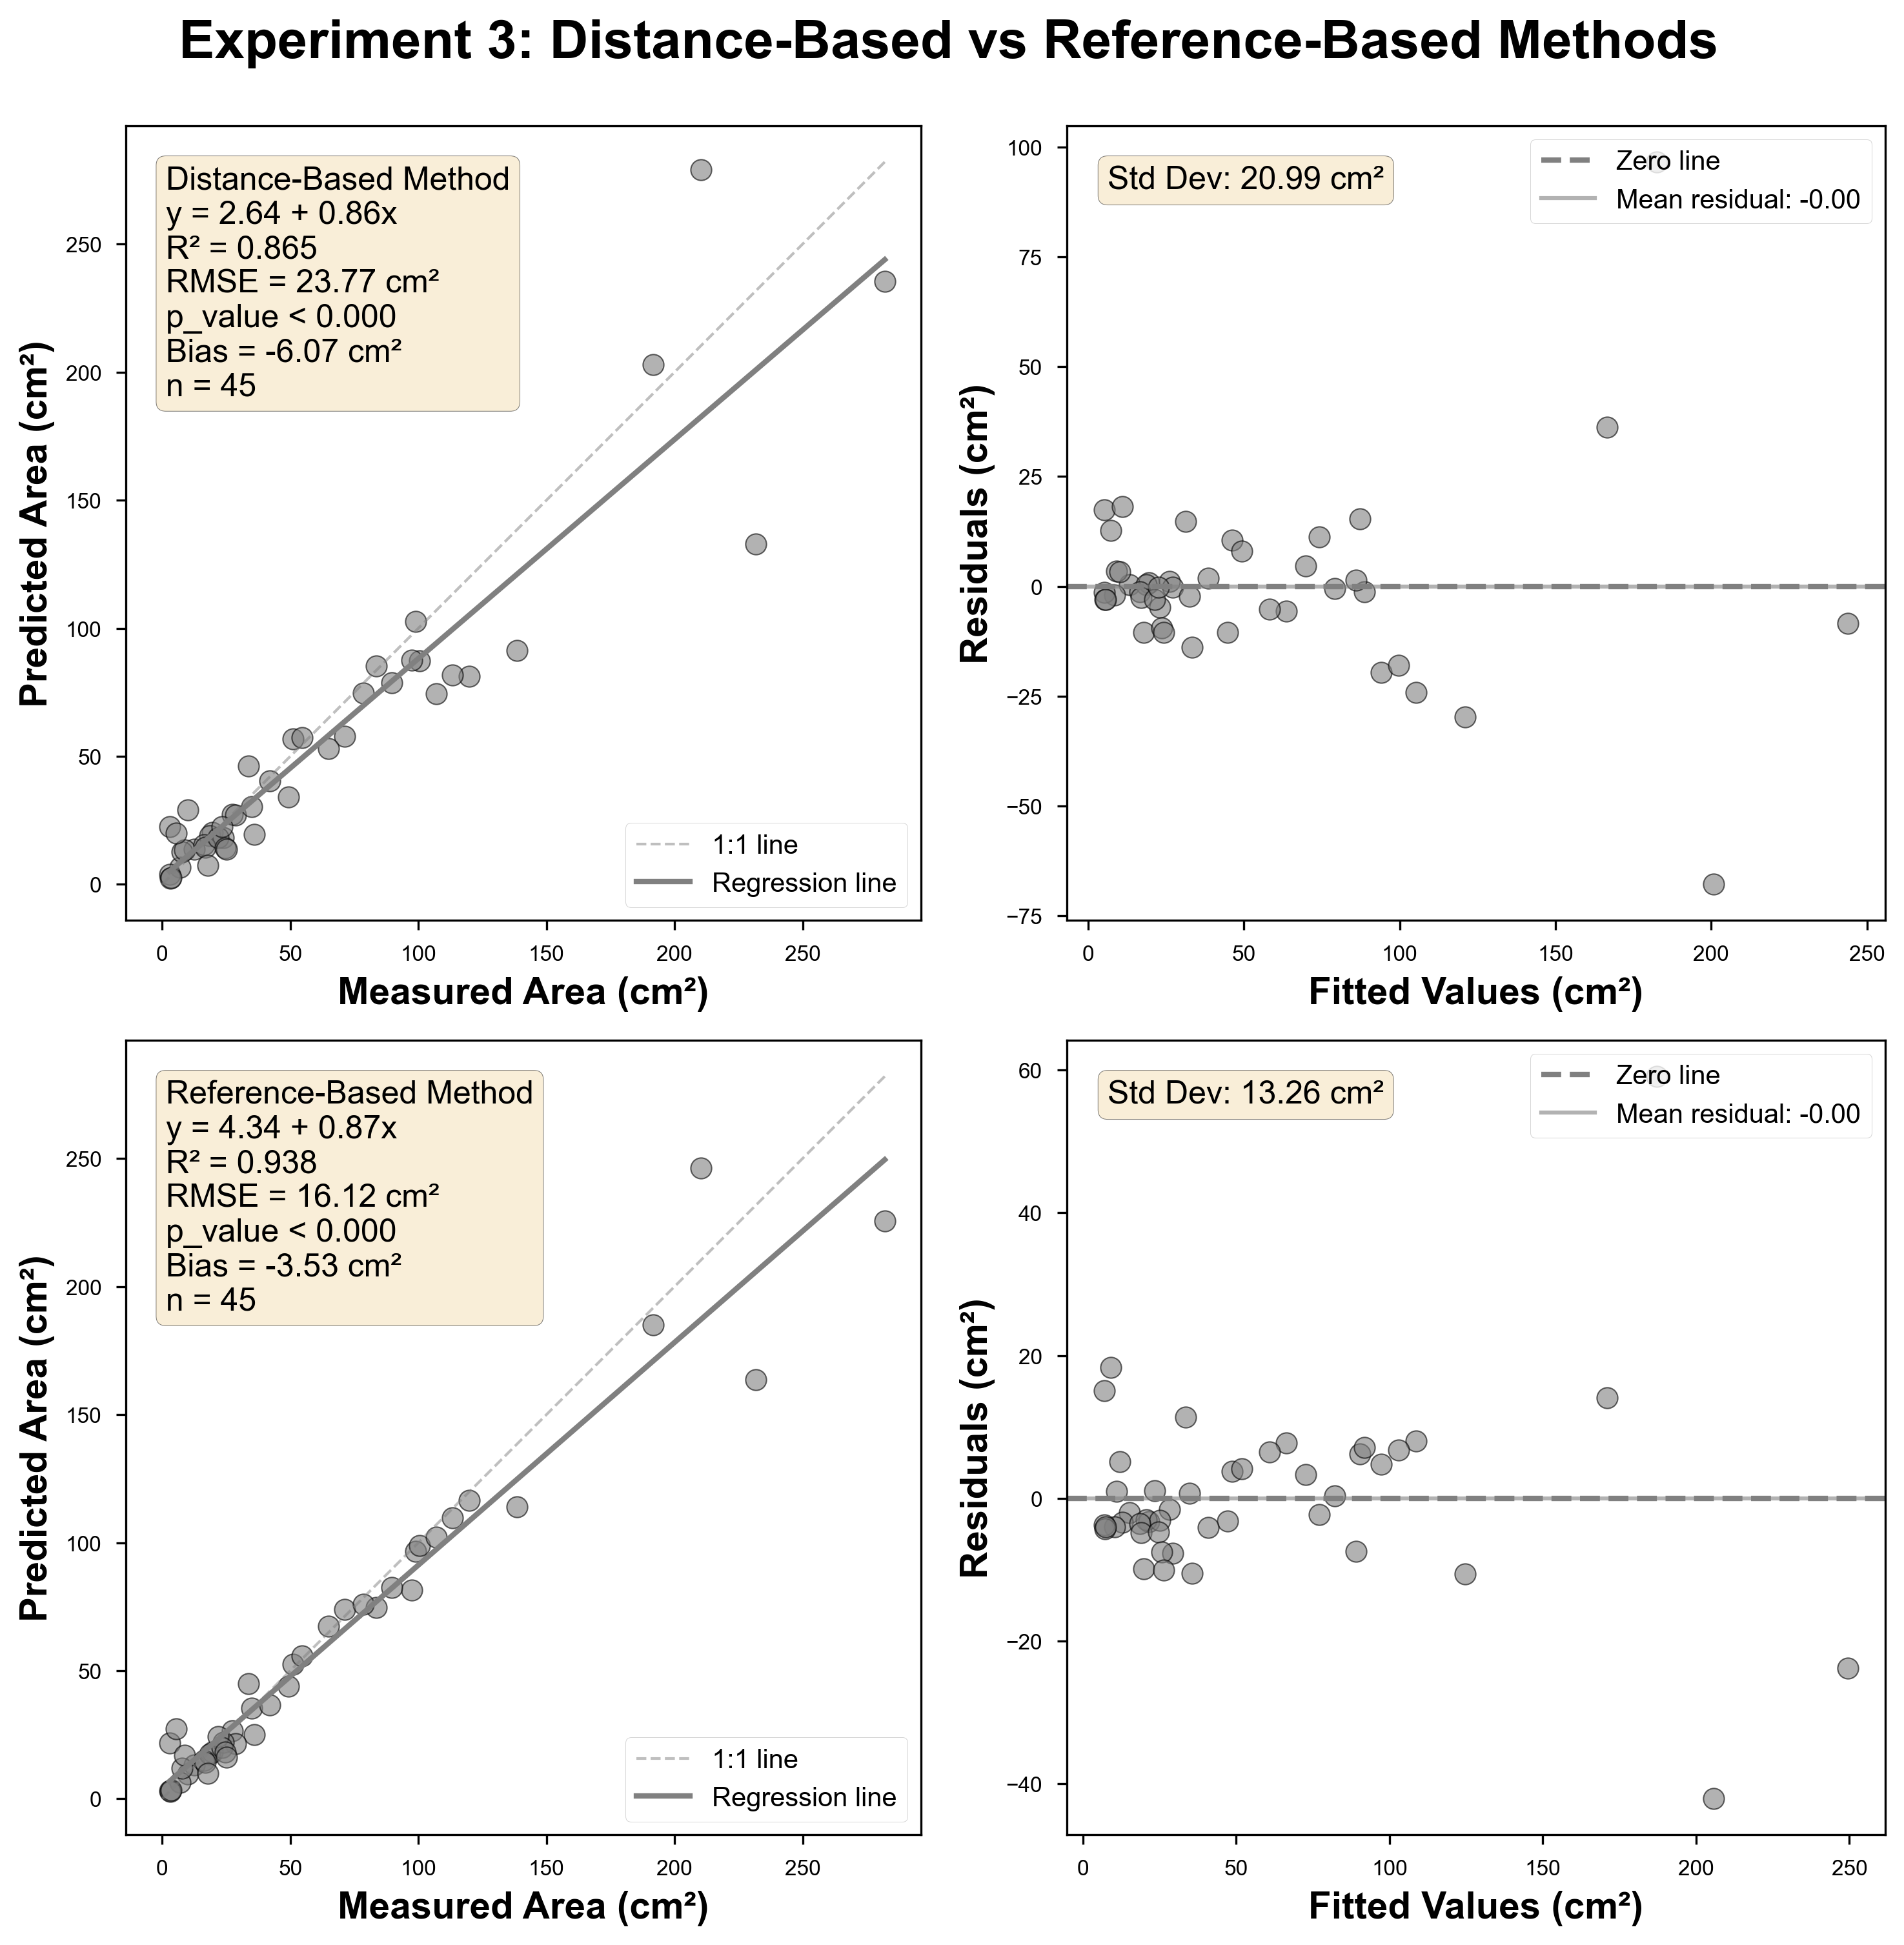

In [55]:
# Uncomment when data is loaded:

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Distance-Based Method - Regression
metrics_distance = plot_regression_analysis(
    distance_data['measured_area_cm2'],
    distance_data['predicted_distance_based_area_cm2'],
    'Distance-Based Method',
    ax=axes[0, 0],
    color='gray'
)

# Distance-Based Method - Residuals
plot_residuals(
    distance_data['measured_area_cm2'],
    distance_data['predicted_distance_based_area_cm2'],
    'Distance-Based Method',
    ax=axes[0, 1],
    color='gray'
)

# Reference-Based Method - Regression
metrics_reference = plot_regression_analysis(
    distance_data['measured_area_cm2'],
    distance_data['predicted_reference_based_area_cm2'],
    'Reference-Based Method',
    ax=axes[1, 0],
    color='gray'
)

# Reference-Based Method - Residuals
plot_residuals(
    distance_data['measured_area_cm2'],
    distance_data['predicted_reference_based_area_cm2'],
    'Reference-Based Method',
    ax=axes[1, 1],
    color='gray'
)

plt.suptitle('Experiment 3: Distance-Based vs Reference-Based Methods', 
             fontsize=20, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('experiment3_method_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

#print("📈 Method comparison code ready - uncomment after loading data")

### Performance by Camera Distance

In [77]:
distance_data.head()

,file,flower,distance_camera_to_ground_cm,measured_area_cm2,predicted_distance_based_area_cm2,predicted_reference_based_area_cm2
0,PXL_20240214_175352365_100cm_F21_.jpg,F21,100,19.696735,20.296706,18.239009
1,PXL_20240214_175033319_60cm_F18_.jpg,F18,60,35.987025,19.537758,25.096238
2,PXL_20240214_173904525_100cm_F13_.jpg,F13,100,98.980447,102.626389,96.598299
3,PXL_20240214_173731980_100cm_F12_.jpg,F12,100,2.883865,22.563655,21.890223
4,PXL_20240214_174053319_60cm_F13_.jpg,F13,60,231.612440,132.928302,163.579053


In [ ]:
# Uncomment when data is loaded:

# Analyze performance at each camera distance
distances = sorted(distance_data['distance_camera_to_ground_cm'].unique())

results_by_distance = []
for dist in distances:
    subset = distance_data[distance_data['distance_camera_to_ground_cm'] == dist]
    
    # Distance-based metrics
    metrics_d = calculate_metrics(subset['measured_area_cm2'], subset['predicted_distance_based_area_cm2'])
    
    # Reference-based metrics
    metrics_r = calculate_metrics(subset['measured_area_cm2'], subset['predicted_reference_based_area_cm2'])
    
    results_by_distance.append({
        'Distance (cm)': dist,
        'n': len(subset),
        'Distance R²': f"{metrics_d['r2']:.3f}",
        'Distance RMSE': f"{metrics_d['rmse']:.2f}",
        'Distance Bias': f"{metrics_d['mean_bias']:.2f}",
        'Reference R²': f"{metrics_r['r2']:.3f}",
        'Reference RMSE': f"{metrics_r['rmse']:.2f}",
        'Reference Bias': f"{metrics_r['mean_bias']:.2f}"
    })

distance_comparison_df = pd.DataFrame(results_by_distance)

print("\n" + "="*120)
print("PERFORMANCE BY CAMERA DISTANCE")
print("="*120)
display(distance_comparison_df)
print("="*120)

# print("📊 Distance analysis code ready - uncomment after loading data")


PERFORMANCE BY CAMERA DISTANCE


,Distance (cm),n,Distance R²,Distance RMSE,Distance Bias,Reference R²,Reference RMSE,Reference Bias
0,60,20,0.739,29.15,-16.90,0.905,17.58,-5.51
1,90,3,0.577,48.54,3.03,0.732,38.61,-7.36
2,100,22,0.969,7.86,2.54,0.976,6.89,-1.20


📊 Distance analysis code ready - uncomment after loading data


### Method Comparison Summary

In [79]:
# Uncomment when data is loaded:

# Overall comparison
method_comparison = pd.DataFrame({
    'Metric': ['R²', 'RMSE (cm²)', 'Mean Bias (cm²)', 'Relative Bias (%)', 'n'],
    'Distance-Based': [
        f"{metrics_distance['r2']:.3f}",
        f"{metrics_distance['rmse']:.2f}",
        f"{metrics_distance['mean_bias']:.2f}",
        f"{metrics_distance['relative_bias']:.2f}",
        metrics_distance['n']
    ],
    'Reference-Based': [
        f"{metrics_reference['r2']:.3f}",
        f"{metrics_reference['rmse']:.2f}",
        f"{metrics_reference['mean_bias']:.2f}",
        f"{metrics_reference['relative_bias']:.2f}",
        metrics_reference['n']
    ],
    'Difference': [
        f"{metrics_distance['r2'] - metrics_reference['r2']:.3f}",
        f"{metrics_distance['rmse'] - metrics_reference['rmse']:.2f}",
        f"{metrics_distance['mean_bias'] - metrics_reference['mean_bias']:.2f}",
        f"{metrics_distance['relative_bias'] - metrics_reference['relative_bias']:.2f}",
        '-'
    ]
})

print("\n" + "="*80)
print("EXPERIMENT 3: METHOD COMPARISON SUMMARY")
print("="*80)
display(method_comparison)
print("="*80)

#print("📊 Method summary code ready - uncomment after loading data")


EXPERIMENT 3: METHOD COMPARISON SUMMARY


,Metric,Distance-Based,Reference-Based,Difference
0,R²,0.865,0.938,-0.073
1,RMSE (cm²),23.77,16.12,7.65
2,Mean Bias (cm²),-6.07,-3.53,-2.54
3,Relative Bias (%),17.18,20.04,-2.86
4,n,45,45,-


---
<a id='summary'></a>
## Summary and Conclusions

This section will synthesize findings from all three experiments.

### Cross-Experiment Comparison


COMPREHENSIVE SUMMARY: ALL EXPERIMENTS


,Experiment,R²,RMSE (cm²),Mean Bias (cm²),Sample Size
0,Exp 1: Indoor (v1.0),0.936,19.99,-2.37,75
1,Exp 1: Indoor (v2.0),0.965,14.69,0.23,75
2,Exp 2: Outdoor (v2.0),0.919,112.51,-33.31,61
3,Exp 3: Distance-Based,0.865,23.77,-6.07,45
4,Exp 3: Reference-Based,0.938,16.12,-3.53,45


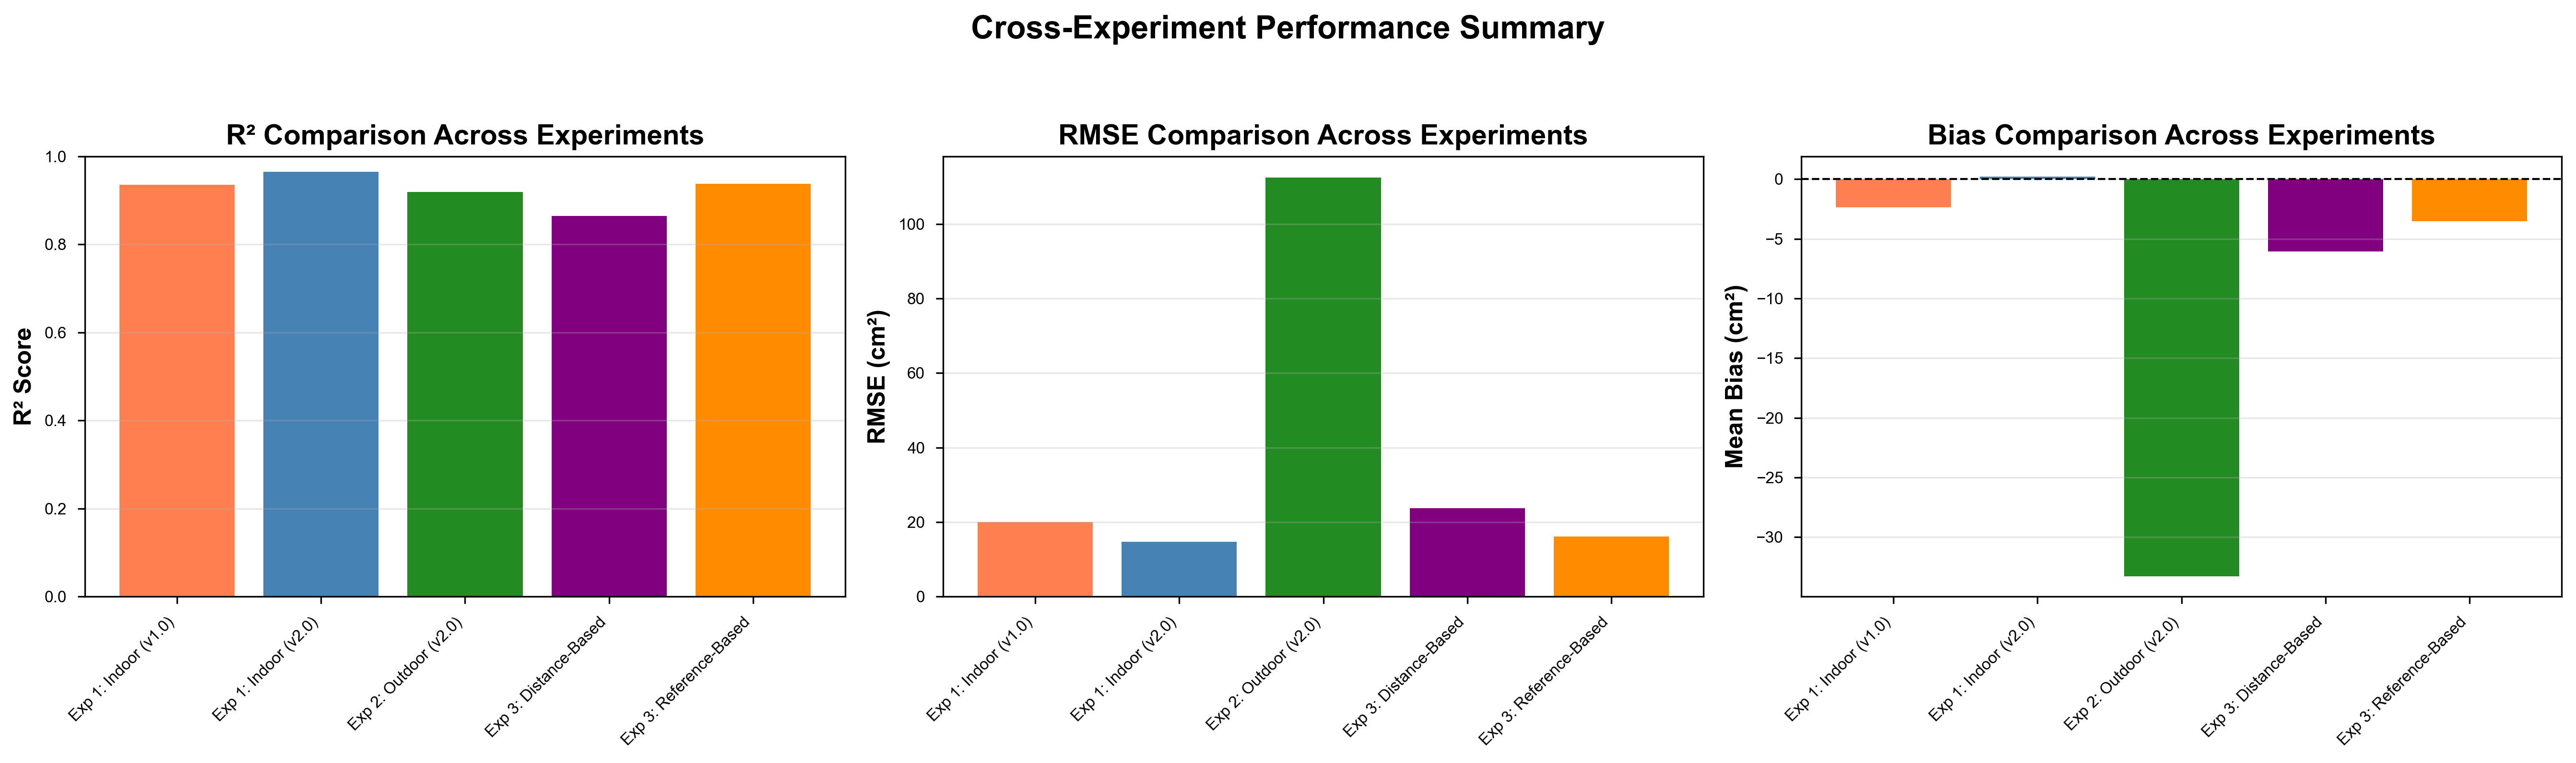

📊 Summary visualization code ready - uncomment after loading all data


In [80]:
# Uncomment when all data is loaded:

# Create comprehensive summary table
summary_table = pd.DataFrame({
    'Experiment': [
        'Exp 1: Indoor (v1.0)',
        'Exp 1: Indoor (v2.0)',
        'Exp 2: Outdoor (v2.0)',
        'Exp 3: Distance-Based',
        'Exp 3: Reference-Based'
    ],
    'R²': [
        f"{metrics_v1_reg['r2']:.3f}",
        f"{metrics_v2_reg['r2']:.3f}",
        f"{metrics_outdoor['r2']:.3f}",
        f"{metrics_distance['r2']:.3f}",
        f"{metrics_reference['r2']:.3f}"
    ],
    'RMSE (cm²)': [
        f"{metrics_v1_reg['rmse']:.2f}",
        f"{metrics_v2_reg['rmse']:.2f}",
        f"{metrics_outdoor['rmse']:.2f}",
        f"{metrics_distance['rmse']:.2f}",
        f"{metrics_reference['rmse']:.2f}"
    ],
    'Mean Bias (cm²)': [
        f"{metrics_v1_reg['mean_bias']:.2f}",
        f"{metrics_v2_reg['mean_bias']:.2f}",
        f"{metrics_outdoor['mean_bias']:.2f}",
        f"{metrics_distance['mean_bias']:.2f}",
        f"{metrics_reference['mean_bias']:.2f}"
    ],
    'Sample Size': [
        metrics_v1_reg['n'],
        metrics_v2_reg['n'],
        metrics_outdoor['n'],
        metrics_distance['n'],
        metrics_reference['n']
    ]
})

print("\n" + "="*100)
print("COMPREHENSIVE SUMMARY: ALL EXPERIMENTS")
print("="*100)
display(summary_table)
print("="*100)

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R² comparison
r2_values = [float(x) for x in summary_table['R²']]
axes[0].bar(range(len(r2_values)), r2_values, 
            color=['coral', 'steelblue', 'forestgreen', 'purple', 'darkorange'])
axes[0].set_xticks(range(len(r2_values)))
axes[0].set_xticklabels(summary_table['Experiment'], rotation=45, ha='right')
axes[0].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('R² Comparison Across Experiments', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1])

# RMSE comparison
rmse_values = [float(x) for x in summary_table['RMSE (cm²)']]
axes[1].bar(range(len(rmse_values)), rmse_values,
            color=['coral', 'steelblue', 'forestgreen', 'purple', 'darkorange'])
axes[1].set_xticks(range(len(rmse_values)))
axes[1].set_xticklabels(summary_table['Experiment'], rotation=45, ha='right')
axes[1].set_ylabel('RMSE (cm²)', fontsize=12, fontweight='bold')
axes[1].set_title('RMSE Comparison Across Experiments', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Bias comparison
bias_values = [float(x) for x in summary_table['Mean Bias (cm²)']]
axes[2].bar(range(len(bias_values)), bias_values,
            color=['coral', 'steelblue', 'forestgreen', 'purple', 'darkorange'])
axes[2].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[2].set_xticks(range(len(bias_values)))
axes[2].set_xticklabels(summary_table['Experiment'], rotation=45, ha='right')
axes[2].set_ylabel('Mean Bias (cm²)', fontsize=12, fontweight='bold')
axes[2].set_title('Bias Comparison Across Experiments', fontsize=14, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Cross-Experiment Performance Summary', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
#plt.savefig('cross_experiment_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("📊 Summary visualization code ready - uncomment after loading all data")

### Key Findings and Recommendations

**This section will be populated after running the analyses. Key points to address:**

#### Experiment 1 (Indoor Benchmark):
- Quantify improvement of FloralArea 2.0 over 1.0
- Discuss impact of SAM3 segmentation
- Compare computational efficiency

#### Experiment 2 (Outdoor Performance):
- Evaluate robustness in complex backgrounds
- Identify challenging conditions
- Discuss practical field applications

#### Experiment 3 (Distance vs Reference):
- Compare accuracy of both methods
- Analyze performance across distances
- Provide recommendations for field deployment

#### Overall Recommendations:
- Best practices for image capture
- Method selection guidelines
- Future improvements

---
## Export Results

In [ ]:
# Uncomment when all analyses are complete:

# # Save summary table to CSV
# summary_table.to_csv('floralarea_2.0_summary.csv', index=False)
# print("✓ Summary table saved to 'floralarea_2.0_summary.csv'")

# # Save experiment-specific results
# if 'comparison_df' in locals():
#     comparison_df.to_csv('experiment1_comparison.csv', index=False)
#     print("✓ Experiment 1 results saved")

# if 'distance_comparison_df' in locals():
#     distance_comparison_df.to_csv('experiment3_distance_comparison.csv', index=False)
#     print("✓ Experiment 3 distance analysis saved")

# if 'method_comparison' in locals():
#     method_comparison.to_csv('experiment3_method_comparison.csv', index=False)
#     print("✓ Experiment 3 method comparison saved")

print("💾 Export code ready - uncomment after completing analyses")

---
## Notes and Next Steps

### To Use This Notebook:

1. **Load Your Data**: Replace the placeholder data loading code with your actual CSV files
2. **Verify Column Names**: Ensure your data has the expected column names
3. **Run Analyses**: Uncomment the analysis code sections and run them
4. **Interpret Results**: Review the visualizations and statistical summaries
5. **Document Findings**: Add observations and insights to the markdown cells

### Required Data Files:

- **Experiment 1**: Indoor benchmark data with FloralArea 1.0 and 2.0 predictions
- **Experiment 2**: Outdoor data with FloralArea 2.0 predictions
- **Experiment 3**: Multi-distance data with both distance-based and reference-based predictions

### Tips for Success:

- Start with Experiment 1 to validate the approach
- Ensure data quality (no missing values, correct units)
- Save intermediate results as you progress
- Document any data cleaning or preprocessing steps
- Keep track of which images were used for calibration vs testing

---

*Notebook created for FloralArea 2.0 evaluation*  
*Last updated: November 2025*